### There are several ways to establish connection to local postgresql db but we will use pandas and sqlalchemy libraries

### To install it RUN THE NEXT CELL BY CLICKING ON IT AND SHIFT+ENTER or click RUN BUTTON ABOVE

In [2]:
!pip install pandas sqlalchemy
!pip install psycopg2-binary

### As now we have proper libraries we can import and use them 

### Execute the following cell 

In [3]:
import pandas as pd
from sqlalchemy import create_engine

def connect_to_db(dbname: str, user: str, password: str, host: str = "localhost", port: str = "5432"):
    try:
        conn_str = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"
        engine = create_engine(conn_str)
        print(f"Engine created for database: {dbname}")
        return engine
    except Exception as e:
        print(f"Error creating engine for {dbname}: {e}")
        return None


### in previous cell we creted connect_to_db function which we can reuse to connect to both of our DBs, we just need to provide propper attributers. 

### In the next cell you can find example of establishing connection to SRC DB and reading data from s1.s1_channels into separate pandas dataframe

### Execute the following cell 

In [5]:
src_engine = connect_to_db(
    dbname="dwh_src_hw_db",
    user="postgres",
    password="postgres"
)

s1_channels_df = pd.read_sql("SELECT * FROM s1.s1_channels", src_engine)
s1_channels_df

Engine created for database: dwh_src_hw_db


,channel_id,channel_name,channel_location
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
153,154,YAOBAO.COM,Internet
154,155,CATALOG.ONLINER.BY,Internet
155,156,5ELEMENT.BY,Internet
156,157,ALLEGRO.PL,Internet


 ## YOUR TASK IS TO ESTABLISH SEPARATE 

 trg_engine 

 ## and conect to dwh_hw_db in the next cell

In [6]:
trg_engine = connect_to_db(
    dbname="dwh_hw_db",
    user="postgres",
    password="postgres"
)
lnd_s1_channels_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_channels", trg_engine)
lnd_s1_channels_df

Engine created for database: dwh_hw_db


,channel_id,channel_name,channellocation
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
151,152,EBAY.COM,N/A - Internet
152,153,ALIEXPRESS.COM,N/A - Internet
153,154,YAOBAO.COM,N/A - Internet
154,155,CATALOG-ONLINER.BY,N/A - Internet


#### AS we have 2 DFs with data from 2 tables we need to compare them. To do so we can create separate DF s1_channels_comparison_df

### Execute the following cell 

In [7]:
s1_channels_comparison_df = s1_channels_df.merge(
    lnd_s1_channels_df,
    on='channel_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True  
)
s1_channels_comparison_df

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge
0,1,STORE - 1,621 Hovde Circle,STORE - 1,621 Hovde Circle,both
1,10,STORE - 10,6840 Pennsylvania Terrace,STORE - 10,6840 Pennsylvania Terrace,both
2,100,STORE - 100,72760 Helena Avenue,STORE - 100,72760 Helena Avenue,both
3,101,STORE - 101,40 Lyons Place,STORE - 101,40 Lyons Place,both
4,102,STORE - 102,04 Ludington Pass,STORE - 102,04 Ludington Pass,both
...,...,...,...,...,...,...
153,95,STORE - 95,6354 Lukken Circle,STORE - 95,6354 Lukken Circle,both
154,96,STORE - 96,1 Lighthouse Bay Way,STORE - 96,1 Lighthouse Bay Way,both
155,97,STORE - 97,03 Moland Parkway,STORE - 97,03 Moland Parkway,both
156,98,STORE - 98,24450 Kim Center,STORE - 98,24450 Kim Center,both


### Since we use indicator=True in the merge, pandas automatically provides the _merge column with values left_only, right_only, or both for the ID values.

### However, we want to make the statuses more meaningful, similar to what we did in SQL and also check for differences in other attributes, not just IDs.
### For this reason, I have prepared a separate function specifically for computing reconciliation_status for the channels table.

### Execute the following cell 

In [8]:
def get_s1_channels_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['channel_name_src'] != row['channel_name_lnd']:
        mismatches.append('channel_name')
    if row['channel_location'] != row['channellocation']:
        mismatches.append('channel_location')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

### Since this function expects a single row as input, we can apply it to our s1_channel_comparison_df and create a new column to store the adapted reconciliation statuses.

### Execute the following cell 


In [9]:
s1_channels_comparison_df['reconciliation_status'] = s1_channels_comparison_df.apply(get_s1_channels_reconciliation_status, axis=1)

### And now, let’s keep only the rows with discrepancies (i.e., excluding rows where everything matches).

In [10]:
s1_channels_issues_df = s1_channels_comparison_df[s1_channels_comparison_df['reconciliation_status'] != 'Match']
display(s1_channels_issues_df.head(20))

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge,reconciliation_status
58,151,AMAZON.COM,Internet,AMAZON.COM,N/A - Internet,both,Mismatch in channel_location
59,152,EBAY.COM,Internet,EBAY.COM,N/A - Internet,both,Mismatch in channel_location
60,153,ALIEXPRESS.COM,Internet,ALIEXPRESS.COM,N/A - Internet,both,Mismatch in channel_location
61,154,YAOBAO.COM,Internet,YAOBAO.COM,N/A - Internet,both,Mismatch in channel_location
62,155,CATALOG.ONLINER.BY,Internet,CATALOG-ONLINER.BY,N/A - Internet,both,"Mismatch in channel_name, channel_location"
63,156,5ELEMENT.BY,Internet,5ELEMENT.BY,N/A - Internet,both,Mismatch in channel_location
64,157,ALLEGRO.PL,Internet,NaN,NaN,left_only,Only in source
65,158,AMAZON.COM,Internet,NaN,NaN,left_only,Only in source


# Task: Reconcile all other table pairs from SRC and LND, similar to what we did for the channels table.

## Instructions:

### Tables to compare:

###### s1.s1_products → lnd.lnd_s1_products
###### s1.s1_sales → lnd.lnd_s1_sales
###### s2.s2_channels → lnd.lnd_s2_channels
###### s2.s2_client_sales → lnd.lnd_s2_client_sales
###### s2.s2_clients → lnd.lnd_s2_clients
###### s2.s2_locations → lnd.lnd_s2_locations

## For each table pair:

### 1. Load the SRC and LND tables into pandas DataFrames.
### 2. Perform a full outer merge on the primary key column(s).
### 3. Apply a function like get_reconciliation_status(row) to classify each row into statuses:
###### 'Only in source'
###### 'Only in landing'
###### 'Mismatch in <column_name>'
###### 'Match'

### Keep only rows with issues (statuses != 'Match').

## 4. Create a consolidated result DataFrame with the following columns:

###### table_name	Name of the table being compared
###### key_column	Primary key column used for reconciliation
###### src_id	ID value from source table
###### trg_id	ID value from landing table
###### reconciliation_status	Status of the row (Only in source, Only in landing, etc.)

## 5. Populate the final result DataFrame with all discrepancies from all table comparisons.

### Tips / Methods:

### Use pd.merge(..., how='outer', indicator=True) to combine SRC and LND tables.
### Apply your reconciliation status function row-wise with df.apply(..., axis=1).
### Filter only rows with issues using df[df['reconciliation_status'] != 'Match'].
### Concatenate multiple issues_df DataFrames using pd.concat([...], ignore_index=True) to create the final consolidated DataFrame.

In [11]:
#s1_products -> lnd_s1_products
# Step 1: Load Source and Landing tables into pandas DataFrames
s1_products_src_df = pd.read_sql("SELECT * FROM s1.s1_products", src_engine)
s1_products_lnd_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_products", trg_engine)


# Step 2: Perform a Full Outer Merge on the Primary Key column
s1_products_comparison_df = s1_products_src_df.merge(
    s1_products_lnd_df,
    on='product_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)

# Step 3: Define row-wise status classification function
def get_s1_products_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if str(row['cost_src']) != str(row['cost_lnd']):
        mismatches.append('cost')
    if row['product_name_src'] != row['product_name_lnd']:
        mismatches.append('product_name')
        
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

# Step 4: Apply status classification row-by-row
s1_products_comparison_df['reconciliation_status'] = s1_products_comparison_df.apply(get_s1_products_reconciliation_status, axis=1)
# Step 5: Filter out perfect matches to keep only rows with issues
s1_products_issues_df = s1_products_comparison_df[s1_products_comparison_df['reconciliation_status'] != 'Match']

# Step 6: Display the first 20 discrepancies for Data Quality analysis
display(s1_products_issues_df.head(20))

,product_id,cost_src,product_name_src,cost_lnd,product_name_lnd,_merge,reconciliation_status
45,50,NaN,NaN,9.06,helmet,right_only,Only in landing


In [12]:
#s1_clients -> lnd_s1_clients
# Step 1: Load Source and Landing tables into pandas DataFrames
s1_clients_src_df = pd.read_sql("SELECT * FROM s1.s1_clients", src_engine)
s1_clients_lnd_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_clients", trg_engine)

# Step 2: Perform a Full Outer Merge on the Primary Key column
s1_clients_comparison_df = s1_clients_src_df.merge(
    s1_clients_lnd_df,
    on='client_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)

# Step 3: Define row-wise status classification function
def get_s1_clients_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    # Check for discrepancies in key data attributes
    if row['first_name_src'] != row['first_name_lnd']:
        mismatches.append('first_name')
    if row['last_name_src'] != row['last_name_lnd']:
        mismatches.append('last_name')
    if row['email_src'] != row['email_lnd']:
        mismatches.append('email')
    if str(row['phone_src']) != str(row['phone_lnd']):
        mismatches.append('phone')
    if str(row['first_purchase_src']) != str(row['first_purchase_lnd']):
        mismatches.append('first_purchase')
        
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

# Step 4: Apply status classification row-by-row
s1_clients_comparison_df['reconciliation_status'] = s1_clients_comparison_df.apply(
    get_s1_clients_reconciliation_status, 
    axis=1
)

# Step 5: Filter out perfect matches to keep only rows with issues
s1_clients_issues_df = s1_clients_comparison_df[s1_clients_comparison_df['reconciliation_status'] != 'Match']

# Step 6: Display the first 20 discrepancies for Data Quality analysis
display(s1_clients_issues_df.head(20))

,client_id,first_name_src,middle_name_src,last_name_src,email_src,phone_src,first_purchase_src,first_name_lnd,middle_name_lnd,last_name_lnd,email_lnd,phone_lnd,first_purchase_lnd,_merge,reconciliation_status
676,699,Christean,Alyce,Yegorkin,ayegorkinje@opera.com,+5987059266523,24-SEP-00,Christean,Alyce,Peterson,ayegorkinje@opera.com,+5987059266523,24-SEP-00,both,Mismatch in last_name
679,700,Gilemette,Amii,Cantrell,acantrelljf@rakuten.co.jp,+2349166424398,23-SEP-00,Gilemette,Amii,Cantrell,acantrelljf@rakuten.co.jp,+2345678903,23-SEP-00,both,Mismatch in phone


In [14]:
#s1_sales -> lnd_s1_sales
# Step 1: Load Source and Landing tables into pandas DataFrames
s1_sales_src_df = pd.read_sql("SELECT client_id, channel_id, sale_date, units, product_id, purchase_date FROM s1.s1_sales", src_engine)
s1_sales_lnd_df = pd.read_sql("SELECT client_id, channel_id, sale_date, units, product_id, purchase_date FROM lnd.lnd_s1_sales", trg_engine)

# Step 2: Perform a Full Outer Merge on the Composite Key
s1_sales_comparison_df = s1_sales_src_df.merge(
    s1_sales_lnd_df,
    on=['client_id', 'product_id', 'sale_date'],
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)

# Step 3: Define status classification function
def get_s1_sales_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in target'  
    
    if str(row['channel_id_src']) != str(row['channel_id_lnd']):
        return 'Mismatch in channel_id'
    if str(row['units_src']) != str(row['units_lnd']):
        return 'Mismatch in units'
    if str(row['purchase_date_src']) != str(row['purchase_date_lnd']):
        return 'Mismatch in purchase_date'
    
    return 'Match'

# Step 4: Apply status classification row-by-row
s1_sales_comparison_df['reconciliation_status'] = s1_sales_comparison_df.apply(
    get_s1_sales_reconciliation_status, 
    axis=1
)

# Step 5: Filter out perfect matches to keep only rows with issues
s1_sales_issues_df = s1_sales_comparison_df[s1_sales_comparison_df['reconciliation_status'] != 'Match']

# Step 6: Display the first 20 discrepancies for Data Quality analysis
display(s1_sales_issues_df.head(20))

,client_id,channel_id_src,sale_date,units_src,product_id,purchase_date_src,channel_id_lnd,units_lnd,purchase_date_lnd,_merge,reconciliation_status
195,104,123,03-MAY-06,14,35,09-MAY-06,NaN,NaN,NaN,left_only,Only in source
327,108,36,20-OCT-05,1,23,21-OCT-05,NaN,NaN,NaN,left_only,Only in source
451,110,110,17-APR-05,4,8,25-APR-05,NaN,NaN,NaN,left_only,Only in source
478,112,84,19-JAN-06,11,10,21-JAN-06,NaN,NaN,NaN,left_only,Only in source
495,112,86,18-NOV-06,11,32,23-NOV-06,NaN,NaN,NaN,left_only,Only in source
553,114,24,23-SEP-05,4,16,30-SEP-05,NaN,NaN,NaN,left_only,Only in source
695,118,130,05-APR-05,2,36,06-APR-05,NaN,NaN,NaN,left_only,Only in source
802,121,125,26-APR-05,8,27,02-MAY-05,NaN,NaN,NaN,left_only,Only in source
878,123,98,26-MAR-05,7,50,03-APR-05,NaN,NaN,NaN,left_only,Only in source
938,125,83,18-AUG-05,7,31,25-AUG-05,NaN,NaN,NaN,left_only,Only in source


In [16]:
#s2_channels -> lnd_s2_channels
# Step 1: Load Source and Landing tables into pandas DataFrames
s2_channels_src_df = pd.read_sql("SELECT * FROM s2.s2_channels", src_engine)
s2_channels_lnd_df = pd.read_sql("SELECT * FROM lnd.lnd_s2_channels", trg_engine)

# Step 2: Perform a Full Outer Merge on the Primary Key
s2_channels_comparison_df = s2_channels_src_df.merge(
    s2_channels_lnd_df,
    on='channel_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)

# Step 3: Define status classification function
def get_s2_channels_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in target'
    
    mismatches = []
    if row['channel_name_src'] != row['channel_name_lnd']:
        mismatches.append('channel_name')
        
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

# Step 4: Apply status classification row-by-row
s2_channels_comparison_df['reconciliation_status'] = s2_channels_comparison_df.apply(get_s2_channels_reconciliation_status, axis=1)

# Step 5: Filter out perfect matches
s2_channels_issues_df = s2_channels_comparison_df[s2_channels_comparison_df['reconciliation_status'] != 'Match']

# Step 6: Display results
display(s2_channels_issues_df.head(20))

,channel_id,channel_name_src,location_id_src,channel_name_lnd,location_id_lnd,_merge,reconciliation_status


In [18]:
#s2_clients -> lnd_s2_clients
# Step 1: Load Data 
s2_clients_src_df = pd.read_sql("SELECT client_id, first_name, last_name, email, phone_code, phone_number, first_purchase, valid_from, valid_to FROM s2.s2_clients", src_engine)
s2_clients_lnd_df = pd.read_sql("SELECT client_id, first_name, last_name, email, phone_code, phone_number, first_purchase, valid_from, valid_to FROM lnd.lnd_s2_clients", trg_engine)

# Step 2: Merge on Primary Key
s2_clients_comparison_df = s2_clients_src_df.merge(
    s2_clients_lnd_df,
    on='client_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True)

# Step 3: Custom Row-wise Classification 
def get_s2_clients_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in target'
    
    if str(row['first_name_src']) != str(row['first_name_lnd']):
        return 'Mismatch in first_name'
    if str(row['last_name_src']) != str(row['last_name_lnd']):
        return 'Mismatch in last_name'
    if str(row['email_src']) != str(row['email_lnd']):
        return 'Mismatch in email'
    if str(row['phone_code_src']) != str(row['phone_code_lnd']):
        return 'Mismatch in phone_code'
    if str(row['phone_number_src']) != str(row['phone_number_lnd']):
        return 'Mismatch in phone_number'
    if str(row['first_purchase_src']) != str(row['first_purchase_lnd']):
        return 'Mismatch in first_purchase'
    if str(row['valid_from_src']) != str(row['valid_from_lnd']):
        return 'Mismatch in valid_from'
    if str(row['valid_to_src']) != str(row['valid_to_lnd']):
        return 'Mismatch in valid_to'
    
    return 'Match'

# Step 4: Apply logic
s2_clients_comparison_df['reconciliation_status'] = s2_clients_comparison_df.apply(get_s2_clients_reconciliation_status, axis=1)

# Step 5: Filter issues
s2_clients_issues_df = s2_clients_comparison_df[s2_clients_comparison_df['reconciliation_status'] != 'Match']

# Step 6: Display
display(s2_clients_issues_df.head(20))

,client_id,first_name_src,last_name_src,email_src,phone_code_src,phone_number_src,first_purchase_src,valid_from_src,valid_to_src,first_name_lnd,last_name_lnd,email_lnd,phone_code_lnd,phone_number_lnd,first_purchase_lnd,valid_from_lnd,valid_to_lnd,_merge,reconciliation_status


In [19]:
#s2_locations -> lnd_s2_locations
# Step 1: Load Data
s2_locations_src_df = pd.read_sql("SELECT location_id, location_name FROM s2.s2_locations", src_engine)
s2_locations_lnd_df = pd.read_sql("SELECT location_id, location_name FROM lnd.lnd_s2_locations", trg_engine)

# Step 2: Merge on Primary Key
s2_locations_comparison_df = s2_locations_src_df.merge(
    s2_locations_lnd_df,
    on='location_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)

# Step 3: Custom Row-wise Classification
def get_s2_locations_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in target'
    
    if str(row['location_name_src']) != str(row['location_name_lnd']):
        return 'Mismatch in location_name'
    
    return 'Match'

# Step 4: Apply logic
s2_locations_comparison_df['reconciliation_status'] = s2_locations_comparison_df.apply(get_s2_locations_reconciliation_status, axis=1)

# Step 5: Filter issues
s2_locations_issues_df = s2_locations_comparison_df[s2_locations_comparison_df['reconciliation_status'] != 'Match']

# Step 6: Display
display(s2_locations_issues_df.head(20))

,location_id,location_name_src,location_name_lnd,_merge,reconciliation_status
10,19,NaN,Store at:2 Cambridge Lane,right_only,Only in target
36,38,Store at:4 Dixons Avenue,NaN,left_only,Only in source
37,39,Store at:11 Warriors Park,NaN,left_only,Only in source
39,40,Store at:1 Jason Lane,NaN,left_only,Only in source
40,40,Store at:1 Jason Lane,NaN,left_only,Only in source


In [20]:
#s2_client_sales -> lnd_s2_client_sales
# Step 1: Load Data
s2_client_sales_src_df = pd.read_sql("SELECT client_id, channel_id, saled_at, product_id, product_name, product_price, product_amount, sold_date FROM s2.s2_client_sales", src_engine)
s2_client_sales_lnd_df = pd.read_sql("SELECT client_id, channel_id, saled_at, product_id, product_name, product_price, product_amount, sold_date FROM lnd.lnd_s2_client_sales", trg_engine)

# Step 2: Merge on Composite Key (client_id, product_id, saled_at)
s2_client_sales_comparison_df = s2_client_sales_src_df.merge(
    s2_client_sales_lnd_df,
    on=['client_id', 'product_id', 'saled_at'],
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)

# Step 3: Custom Row-wise Classification (Non-key columns checked only)
def get_s2_client_sales_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in target'
    
    if str(row['channel_id_src']) != str(row['channel_id_lnd']):
        return 'Mismatch in channel_id'
    if str(row['product_name_src']) != str(row['product_name_lnd']):
        return 'Mismatch in product_name'
    if str(row['product_price_src']) != str(row['product_price_lnd']):
        return 'Mismatch in product_price'
    if str(row['product_amount_src']) != str(row['product_amount_lnd']):
        return 'Mismatch in product_amount'
    if str(row['sold_date_src']) != str(row['sold_date_lnd']):
        return 'Mismatch in sold_date'
    
    return 'Match'

# Step 4: Apply logic
s2_client_sales_comparison_df['reconciliation_status'] = s2_client_sales_comparison_df.apply(get_s2_client_sales_reconciliation_status, axis=1)

# Step 5: Filter issues
s2_client_sales_issues_df = s2_client_sales_comparison_df[s2_client_sales_comparison_df['reconciliation_status'] != 'Match']

# Step 6: Display
display(s2_client_sales_issues_df.head(20))

,client_id,channel_id_src,saled_at,product_id,product_name_src,product_price_src,product_amount_src,sold_date_src,channel_id_lnd,product_name_lnd,product_price_lnd,product_amount_lnd,sold_date_lnd,_merge,reconciliation_status
9,cl10,ch18,04-SEP-11,pr118,Lyc White Casual Boots,185.4602857,1,05-SEP-11,NaN,NaN,NaN,NaN,NaN,left_only,Only in source
309,cl27,ch26,28-MAR-10,pr85,Redbag Eight Armed Goddess Sherawali Maa Showp...,124.9477143,3,29-MAR-10,NaN,NaN,NaN,NaN,NaN,left_only,Only in source
565,cl42,ch8,28-SEP-10,pr105,Rialto Boots,161.622,6,29-SEP-10,NaN,NaN,NaN,NaN,NaN,left_only,Only in source
682,cl49,ch11,15-JUN-10,pr95,"Camerii WM64 Elegance Analog Watch - For Men,...",143.2848571,4,16-JUN-10,NaN,NaN,NaN,NaN,NaN,left_only,Only in source
981,cl65,ch4,13-NOV-12,pr111,Shuz Touch Boots,172.6242857,2,14-NOV-12,NaN,NaN,NaN,NaN,NaN,left_only,Only in source


In [23]:
def transform_to_final_format(df, table_name, key_col):
    # If there are no issues in the table, return an empty DataFrame with correct columns
    if df.empty:
        return pd.DataFrame(columns=['table_name', 'key_column', 'src_id', 'trg_id', 'reconciliation_status'])
    
    final_df = pd.DataFrame()
    final_df['table_name'] = [table_name] * len(df)
    final_df['key_column'] = [key_col] * len(df)
    
    # Safely get IDs based on where the record exists
    final_df['src_id'] = df[key_col].where(df['_merge'] != 'right_only')
    final_df['trg_id'] = df[key_col].where(df['_merge'] != 'left_only')
    final_df['reconciliation_status'] = df['reconciliation_status'].values
    
    return final_df

# Concatenate all tables with errors into one final DataFrame
final_reconciliation_report = pd.concat([
    transform_to_final_format(s1_channels_issues_df, 's1_channels', 'channel_id'),
    transform_to_final_format(s1_products_issues_df, 's1_products', 'product_id'),
    transform_to_final_format(s1_clients_issues_df, 's1_clients', 'client_id'),
    transform_to_final_format(s1_sales_issues_df, 's1_sales', 'client_id'),
    transform_to_final_format(s2_channels_issues_df, 's2_channels', 'channel_id'),
    transform_to_final_format(s2_clients_issues_df, 's2_clients', 'client_id'),
    transform_to_final_format(s2_locations_issues_df, 's2_locations', 'location_id'),
    transform_to_final_format(s2_client_sales_issues_df, 's2_client_sales', 'client_id')
], ignore_index=True)

# Display report
display(final_reconciliation_report)

,table_name,key_column,src_id,trg_id,reconciliation_status
0,s1_channels,channel_id,NaN,NaN,Mismatch in channel_location
1,s1_channels,channel_id,NaN,NaN,Mismatch in channel_location
2,s1_channels,channel_id,NaN,NaN,Mismatch in channel_location
3,s1_channels,channel_id,NaN,NaN,Mismatch in channel_location
4,s1_channels,channel_id,NaN,NaN,"Mismatch in channel_name, channel_location"
...,...,...,...,...,...
208,s2_client_sales,client_id,NaN,NaN,Only in source
209,s2_client_sales,client_id,NaN,NaN,Only in source
210,s2_client_sales,client_id,NaN,NaN,Only in source
211,s2_client_sales,client_id,NaN,NaN,Only in source


## Optional task:

### based on the final result DataFrame build visualizatons 

### Total Anomalies per Table
### Reconciliation Summary by Table
### Reconciliation Status Distribution

## Examples are added

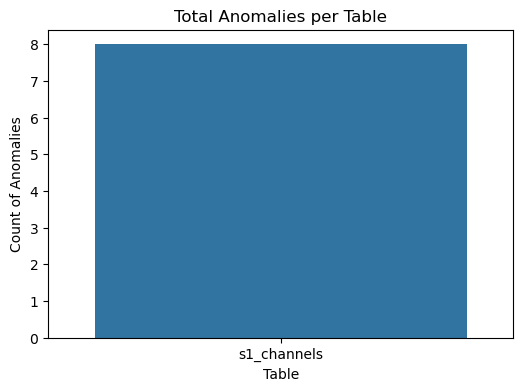

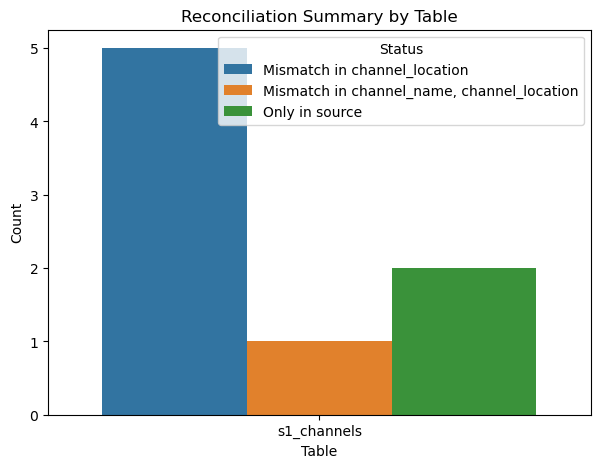

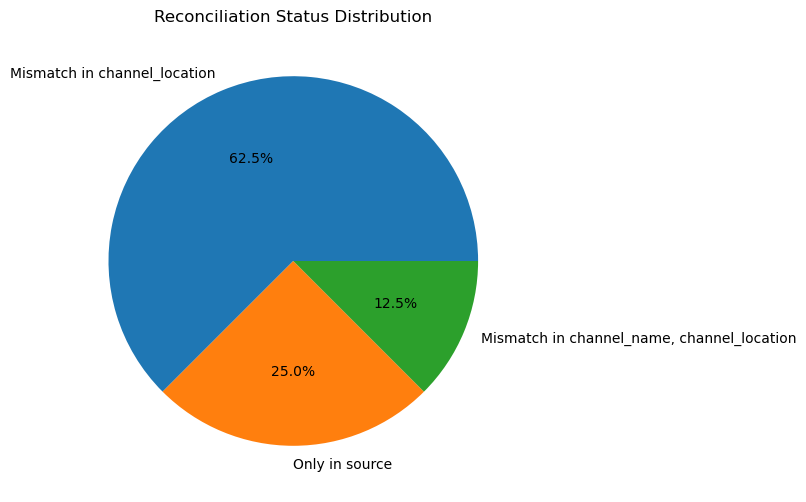